# Healthcare Claims — Part III: Qualitative Factors

Continuation of Parts I–II. The log-scale model of Part II,

$$\log(\text{TotalCost}) = \beta_0 + \beta_1\,\text{LengthOfStay} + \beta_2\,\text{NumRevenueCodes} + \varepsilon, \qquad R^2 = 0.759,$$

used only quantitative predictors. The dataset also contains **categorical** information — most importantly whether the encounter was an **emergency (ER)** or **inpatient (INP)** visit. Here we bring that into the regression with dummy variables.

**Contents**

10. Qualitative factors and dummy encoding
11. ANCOVA: adding `TypeFlag` to the log-cost model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

df = pd.read_csv("https://github.com/thousandoaks/Python4DS-I/raw/main/datasets/HealthcareDataset_PublicRelease.csv",sep=',',parse_dates=['StartDate','EndDate','BirthDate'])
 

enc = (df.groupby('MedicalClaim')
         .agg(TotalCost=('TotalExpenses', 'sum'),
              NumRevenueCodes=('RevenueCode', 'nunique'),
              StartDate=('StartDate', 'min'), EndDate=('EndDate', 'max'),
              TypeFlag=('TypeFlag', 'first'),
              HospitalType=('HospitalType', 'first'),
              County=('County', 'first'))
         .reset_index())
enc['LengthOfStay'] = (enc.EndDate - enc.StartDate).dt.days
enc['LogCost'] = np.log(enc.TotalCost)
print(f'Encounters: {len(enc):,}')

Encounters: 3,361


## 10. Qualitative factors and dummy encoding

Candidate categorical variables at the encounter level:

In [2]:
for col in ['TypeFlag', 'HospitalType', 'County']:
    vc = enc[col].value_counts()
    print(f'{col}: {enc[col].nunique()} levels')
    print(vc.head(4).to_string(), '\n')

TypeFlag: 2 levels
TypeFlag
ER     1871
INP    1490 

HospitalType: 3 levels
HospitalType
HOSPITAL                    3356
HOSPITAL LONG TERM ACUTE       3
REHABILITATION CENTER          2 

County: 19 levels
County
02af982d    1566
425a37b2     574
fd218584     323
89e38653     246 



In [3]:
enc.groupby('TypeFlag').agg(
    n=('TotalCost', 'size'),
    mean_cost=('TotalCost', 'mean'),
    median_cost=('TotalCost', 'median'),
    median_LOS=('LengthOfStay', 'median'),
    median_NRC=('NumRevenueCodes', 'median')).round(0)

,n,mean_cost,median_cost,median_LOS,median_NRC
TypeFlag,,,,,
ER,1871,"11,841.0000","7,551.0000",0.0000,7.0000
INP,1490,"81,623.0000","56,719.0000",4.0000,19.0000


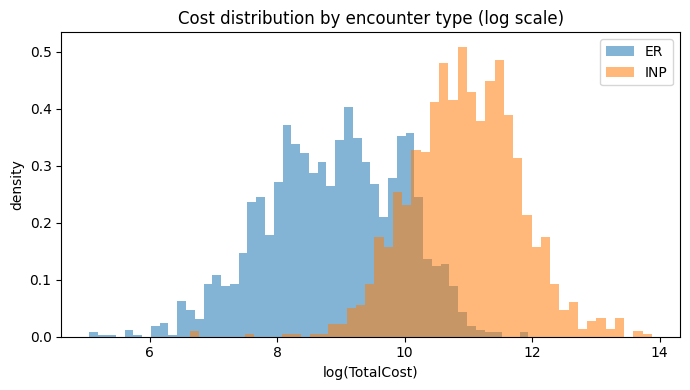

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for t, g in enc.groupby('TypeFlag'):
    ax.hist(g.LogCost, bins=50, alpha=0.55, label=t, density=True)
ax.set_xlabel('log(TotalCost)'); ax.set_ylabel('density')
ax.set_title('Cost distribution by encounter type (log scale)')
ax.legend(); plt.tight_layout(); plt.show()



A categorical variable enters a regression as a **dummy (indicator) variable**. With ER as the reference level,

$$D_i = \begin{cases}1 & \text{if encounter } i \text{ is INP}\\ 0 & \text{if ER}\end{cases}$$

and its coefficient measures the shift in expected log-cost of INP relative to ER, *holding the quantitative predictors fixed*. The open question the regression answers: is inpatient care more expensive **merely because** those patients stay longer and receive more kinds of service (both already in the model), or is there an inpatient premium **on top of** that?

## 11. Adding `TypeFlag` to the log-cost model

$$\log(\text{TotalCost}_i) = \beta_0 + \beta_1\,\text{LengthOfStay}_i + \beta_2\,\text{NumRevenueCodes}_i + \beta_3\,D_i + \varepsilon_i$$

Geometrically: two **parallel** regression planes, one per encounter type, separated vertically by $\beta_3$.

In [5]:
ancova = smf.ols('LogCost ~ LengthOfStay + NumRevenueCodes + C(TypeFlag)',
                 data=enc).fit()

res = pd.concat([ancova.params, ancova.bse, ancova.tvalues,
                 ancova.pvalues, ancova.conf_int()], axis=1)
res.columns = ['coef', 'std err', 't', 'p-value', 'CI 2.5%', 'CI 97.5%']
res['% effect'] = (np.exp(res.coef) - 1) * 100
res['% CI low'] = (np.exp(res['CI 2.5%']) - 1) * 100
res['% CI high'] = (np.exp(res['CI 97.5%']) - 1) * 100

print(f'R-squared          = {ancova.rsquared:.3f}   (Part II model: 0.759)')
print(f'Adjusted R-squared = {ancova.rsquared_adj:.3f}')
res.round(4)

R-squared          = 0.767   (Part II model: 0.759)
Adjusted R-squared = 0.767


,coef,std err,t,p-value,CI 2.5%,CI 97.5%,% effect,% CI low,% CI high
Intercept,7.9443,0.0236,336.6950,0.0000,7.8981,7.9906,"281,850.8193","269,104.3177","295,200.8524"
C(TypeFlag)[T.INP],0.4032,0.0371,10.8762,0.0000,0.3305,0.4759,49.6582,39.1665,60.9408
LengthOfStay,0.0111,0.0032,3.4744,0.0005,0.0049,0.0174,1.1212,0.4870,1.7595
NumRevenueCodes,0.1327,0.0026,51.6422,0.0000,0.1276,0.1377,14.1863,13.6127,14.7629


**Interpretation.**

* **`TypeFlag[INP]`**: $\hat\beta_3 = 0.4032$ ($t = 10.9$, $p \approx 4\times10^{-27}$; 95% CI [0.331, 0.476]). An inpatient encounter costs $e^{0.4032} \approx 1.50$ times an ER encounter *with the same length of stay and the same service breadth* — an **inpatient premium of +49.7%** (95% CI [+39%, +61%]). So no: length of stay and service mix do **not** fully explain the ER/INP gap; being admitted carries a large cost premium of its own (room & board rates, staffing intensity, case severity not captured by our two covariates).
* **`NumRevenueCodes`**: +14.2% per additional service category (95% CI [+13.6%, +14.8%]) — slightly below Part II's +16.3%, since the dummy now absorbs part of the complexity difference between types.
* **`LengthOfStay`**: +1.1% per day (95% CI [+0.5%, +1.8%]), still significant ($p = 0.0005$) but modest.
* All three predictors are significant at any conventional level; $R^2$ rises from 0.759 to **0.767**. A modest gain in fit, but the dummy's value is chiefly **interpretive** — it isolates and quantifies the admission premium.

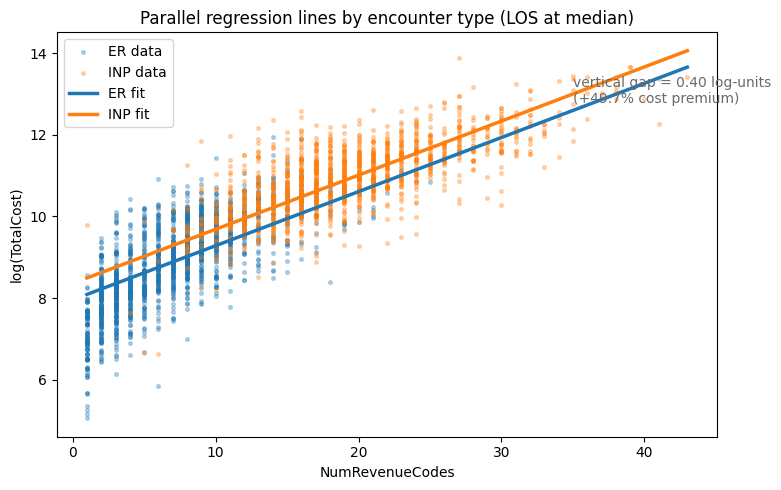

In [6]:
# Visualization: parallel fits vs NumRevenueCodes (LOS held at its median)
b = ancova.params
los_med = enc.LengthOfStay.median()
xs = np.linspace(1, enc.NumRevenueCodes.max(), 100)

fig, ax = plt.subplots(figsize=(8, 5))
colors = {'ER': 'tab:blue', 'INP': 'tab:orange'}
for t, g in enc.groupby('TypeFlag'):
    ax.scatter(g.NumRevenueCodes, g.LogCost, s=7, alpha=0.3, color=colors[t], label=f'{t} data')
for t, d in [('ER', 0), ('INP', 1)]:
    ax.plot(xs, b['Intercept'] + b['C(TypeFlag)[T.INP]']*d
                + b['LengthOfStay']*los_med + b['NumRevenueCodes']*xs,
            color=colors[t], lw=2.5, label=f'{t} fit')
ax.annotate('vertical gap = 0.40 log-units\n(+49.7% cost premium)',
            xy=(35, b['Intercept'] + b['NumRevenueCodes']*35 + 0.2),
            fontsize=10, color='dimgrey')
ax.set_xlabel('NumRevenueCodes'); ax.set_ylabel('log(TotalCost)')
ax.set_title('Parallel regression lines by encounter type (LOS at median)')
ax.legend(); plt.tight_layout(); plt.show()

**What the plot shows.** The two point clouds share the same slope in service breadth, but the inpatient line sits a constant 0.40 log-units above the ER line — the admission premium. On the log scale a constant vertical shift means a constant *percentage* premium (+49.7%) at every level of complexity.

**Conclusion.** Qualitative information enters linear models naturally through dummy variables. Here, encounter type is highly significant even after controlling for utilization: admission itself raises expected cost by about half, holding stay length and service breadth fixed. The parallel-planes (no-interaction) assumption could itself be tested by interacting the dummy with the slopes — left as the natural next step.